In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

Matplotlib is building the font cache; this may take a moment.


In [ ]:
train_dir = "../data/train"
test_dir = "../data/test"

In [ ]:
os.listdir(train_dir)

['happy', 'sad', 'fear', 'surprise', 'neutral', 'angry', 'disgust']

In [ ]:
class_counts = {}

for emotion in os.listdir(train_dir):
    
    emotion_path = os.path.join(train_dir, emotion)

    if os.path.isdir(emotion_path):
        class_counts[emotion] = len(os.listdir(emotion_path))

class_counts

{'happy': 7215,
 'sad': 4830,
 'fear': 4097,
 'surprise': 3171,
 'neutral': 4965,
 'angry': 3995,
 'disgust': 436}

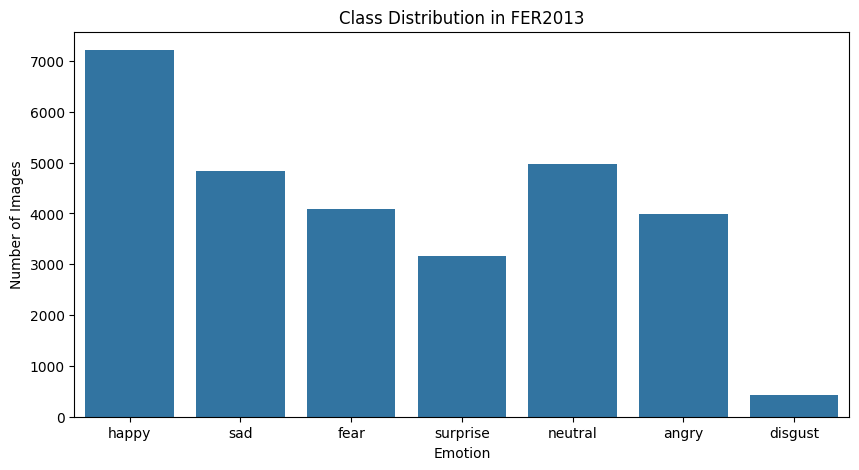

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.title("Class Distribution in FER2013")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")

plt.show()

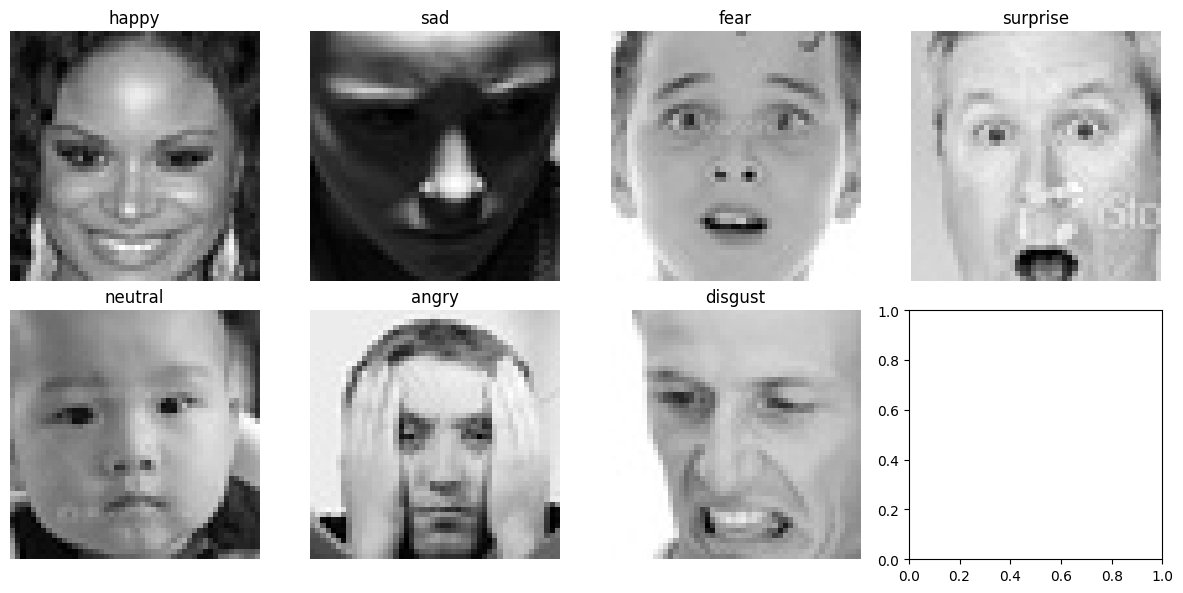

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

axes = axes.flatten()

for idx, emotion in enumerate(os.listdir(train_dir)[:7]):

    emotion_path = os.path.join(train_dir, emotion)

    image_name = random.choice(os.listdir(emotion_path))

    image_path = os.path.join(emotion_path, image_name)

    image = Image.open(image_path)

    axes[idx].imshow(image, cmap="gray")
    axes[idx].set_title(emotion)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
sample_emotion = random.choice(os.listdir(train_dir))

sample_path = os.path.join(
    train_dir,
    sample_emotion,
    random.choice(os.listdir(os.path.join(train_dir, sample_emotion)))
)

image = Image.open(sample_path)

image_array = np.array(image)

print("Image shape:", image_array.shape)

Image shape: (48, 48)


In [ ]:
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

Minimum pixel value: 22
Maximum pixel value: 199


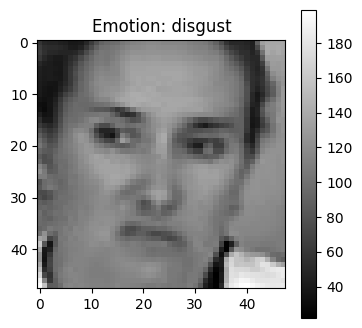

In [ ]:
plt.figure(figsize=(4,4))

plt.imshow(image_array, cmap="gray")

plt.title(f"Emotion: {sample_emotion}")

plt.colorbar()

plt.show()

# EDA Observations

## Dataset Findings

- FER2013 contains grayscale facial images of size 48×48.
- The dataset is imbalanced, especially for the disgust class.
- Several images are blurry, noisy, and low contrast.
- Some emotions visually overlap, especially fear and surprise.
- Small image resolution makes emotion recognition difficult.
- Data augmentation and regularization will likely be important.